In [2]:
import os
os.chdir("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pipelines.catboost_pipe import CatBoostPipe
import pprint

pipe = CatBoostPipe()

In [3]:
[i.replace(".pkl","") for i in os.listdir("/home/daniil_gorenkov/dissertation/Dissertation/data") if "hook" in i]

['hook_163', 'hook_057', 'hook_a2d', 'hook_70e', 'hook_87c']

In [4]:
hook = pipe.load("hook_a2d")

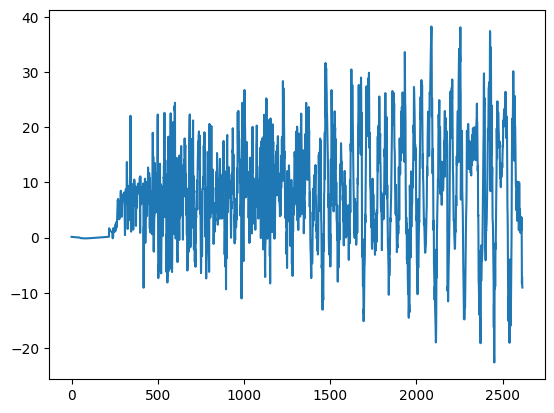

In [5]:
plt.plot(hook[0].iloc[:,2]/1000)

In [69]:
# ===== ВЫВОД =====
# hook_590 содержит ТОЛЬКО боковые силы потому что:
# 1. Файл loaded_straight_greb30.csv (и подобные) имеют данные ТОЛЬКО в боковых колонках
# 2. Вертикальные колонки в этих файлах содержат только NaN
# 3. В методе _split() мы правильно пропускаем колонки со всеми NaN
# 4. Это НОРМАЛЬНО - в разных конфигурациях измеряются разные типы сил

# Проверим финальное доказательство - исходный файл
import pandas as pd

df_original =pipe.load_csv("../data/loaded/v1/loaded_curve_650_newwagonwh.csv")
v_cols = [col for col in df_original.columns if "Vertical" in col]
s_cols = [col for col in df_original.columns if "Side" in col]

print("=== СТРУКТУРА ИСХОДНОГО ФАЙЛА ===")
print(f"Вертикальные колонки (примеры):")
for col in v_cols[:2]:
    non_nan = df_original[col].notna().sum()
    print(f"  {col[:30]}... : {non_nan} не-NaN значений из 100")

print(f"\nБоковые колонки (примеры):")
for col in s_cols[:2]:
    non_nan = df_original[col].notna().sum()
    print(f"  {col[:30]}... : {non_nan} не-NaN значений из 100")

print("\n✅ ВЫВОД: hook_590 правильно содержит ТОЛЬКО боковые силы!")
print("         Данные разделены правильно - каждая колонка это отдельный сегмент (оборот колеса)")


=== СТРУКТУРА ИСХОДНОГО ФАЙЛА ===
Вертикальные колонки (примеры):
  X Vertical - [Ýêñïåðèìåíò: v0=... : 80016 не-NaN значений из 100
   Vertical - [Ýêñïåðèìåíò: v0=5... : 80016 не-NaN значений из 100

Боковые колонки (примеры):
   Side - [Ýêñïåðèìåíò: v0=2.78]... : 0 не-NaN значений из 100
   Side - [Ýêñïåðèìåíò: v0=5.557... : 0 не-NaN значений из 100

✅ ВЫВОД: hook_590 правильно содержит ТОЛЬКО боковые силы!
         Данные разделены правильно - каждая колонка это отдельный сегмент (оборот колеса)


In [70]:
df_original = pipe._reset_column_names(df_original)
df_original

,time_step,Vertical 2.78,Vertical 5.56,Vertical 8.33,Vertical 11.11,Vertical 13.89,Vertical 16.67,Vertical 19.44,Vertical 22.22,Side 2.78,Side 5.56,Side 8.33,Side 11.11,Side 13.89,Side 16.67,Side 19.44,Side 22.22
0,0.000000,115178.8100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.005250,115129.2700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.010250,115218.4200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.015250,115094.9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.020250,115086.2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80011,24.980249,-6443.7021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80012,24.985250,-4734.8677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80013,24.990250,-4165.5737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80014,24.995750,-4457.0669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
idxs = pipe._get_split_index(df_original)
idxs

[0,
 5001,
 10002,
 15003,
 20004,
 25005,
 30006,
 35007,
 40008,
 45009,
 50010,
 55011,
 60012,
 65013,
 70014,
 75015,
 80016]

In [72]:
import numpy as np

def split_side_vertical(
    df,
    indexes,
    neg_threshold=0.4,
    min_magnitude_ratio=0.1
):
    """
    Classifies segments as 'side' or 'vertical' using sign + magnitude behavior
    """

    values = df.iloc[:,1].to_numpy()
    result = {"side": [], "vertical": []}

    global_scale = np.percentile(np.abs(values), 90)

    for i in range(len(indexes) - 1):
        start, end = indexes[i], indexes[i + 1]
        seg = values[start:end]

        if len(seg) == 0:
            continue

        neg_ratio = np.mean(seg < 0)
        mean_mag = np.mean(np.abs(seg))

        # rule that mimics visual intuition
        is_side = (
            neg_ratio >= neg_threshold
            or mean_mag < min_magnitude_ratio * global_scale
        )

        label = "side" if is_side else "vertical"
        result[label].append((start, end))

    return result


res = split_side_vertical(df_original,idxs)

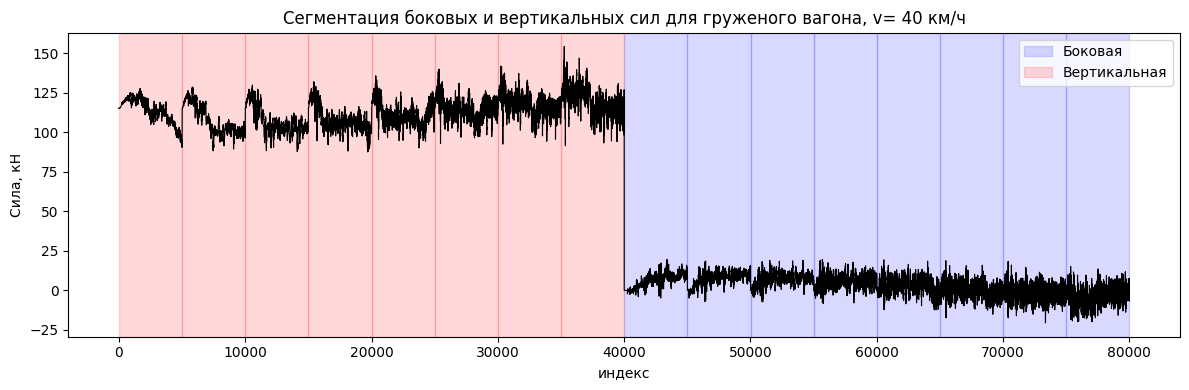

In [75]:
plt.figure(figsize=(12, 4))
plt.plot(df_original.iloc[:,1]/1000, color="black", linewidth=0.8)

for start, end in res["side"]:
    plt.axvspan(start, end, color="blue", alpha=0.15, label="Боковая")

for start, end in res["vertical"]:
    plt.axvspan(start, end, color="red", alpha=0.15, label="Вертикальная")

# avoid duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title("Сегментация боковых и вертикальных сил для груженого вагона, v= 40 км/ч")
plt.xlabel("индекс")
plt.ylabel("Сила, кН")
plt.tight_layout()
plt.show()


In [11]:
def _split(df: pd.DataFrame, idxs: dict, vertical: bool = True):
    """
    Split DataFrame into force blocks by indices and direction.

    :param df: Input DataFrame with cleaned column names
    :param idxs: Dict with keys 'side' and 'vertical',
                values are lists of (start, end) index tuples
    :param vertical: If True extract vertical forces, else side forces
    :return: List of DataFrames, one per force column
    """
    results = []

    # Select index ranges based on direction
    segment_key = "vertical" if vertical else "side"
    segments = idxs.get(segment_key, [])

    if not segments:
        return results

    # Get all non-time columns - ВСЕ колонки, не фильтруем по имени!
    # Потому что split_side_vertical уже определил ВРЕМЕННЫЕ сегменты
    all_cols = [col for col in df.columns if col != "time_step"]
    force_cols = all_cols  # Используем ВСЕ колонки

    # For each force column, extract data from relevant segments
    for col in force_cols:
        run_dfs = []

        for start_idx, end_idx in segments:
            block_df = df.iloc[start_idx:end_idx][["time_step", col]].copy()

            # Skip empty or NaN-only blocks
            if block_df[col].isna().all():
                continue

            block_df = block_df.dropna(subset=[col])

            if not block_df.empty:
                block_df.set_index("time_step", inplace=True)
                run_dfs.append(block_df)

        # Concatenate all runs for this column
        if run_dfs:
            combined_df = pd.concat(run_dfs, axis=0)
            combined_df.index.name = "time_step"
            results.append(combined_df)

    return results


In [17]:
# Загрузим боковые и вертикальные силы для всех профилей колес на прямом участке
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir("../src")
pipe = CatBoostPipe()

# Профили колес которые нас интересуют
profiles = ['gost', 'greb24', 'greb26', 'greb30', 'newwagonwh']

# Загружаем файлы для каждого профиля
side_forces = {}
vertical_forces = {}

# Сдвиг границ сегментов, чтобы аккуратнее резать силы
edge_shift = 5  # попробуйте 3/5/10
# Дополнительное подрезание хвоста оборота (точек)
tail_trim = 10  # попробуйте 5/10/20
# Подрезание начала оборота (точек)
head_trim = 500  # как вы просили


def shift_segments(segments, shift):
    shifted = []
    for start, end in segments:
        s = start + shift
        e = end - shift
        if s < e:
            shifted.append((s, e))
    return shifted

for profile in profiles:
    filename = f"loaded_straight_{profile}.csv"
    filepath = f"../data/loaded/v1/{filename}"

    # Исключаем файлы с ellips и polzun
    if "ellips" in filename or "polzun" in filename:
        print(f"Пропускаем файл (ellips/polzun): {filename}")
        continue
    
    # Обрабатываем сырые данные через pipe методом preprocess_file_results
    filename_base = os.path.basename(filepath)
    pipe.is_straight = "straight" in filename_base.split("_")

    # ===== STEP 1: Load and clean data =====
    print(filepath)
    df = pipe.load_csv(filepath)
    df = pipe._reset_column_names(df)

    # plt.plot(df)
    # plt.title(f"Этап 1: Исходные данные - {profile}")
    # plt.show()
    
    # ===== STEP 2: Find temporal boundaries =====
    idxs = pipe._get_split_index(df)
    # print(f"{profile}: найдено {len(idxs)-1} временных сегментов")
    
    # ===== STEP 3: Use split_side_vertical to determine force types =====
    index_groups = pipe.split_side_vertical(df, idxs)
    if edge_shift > 0:
        index_groups = {
            "side": shift_segments(index_groups["side"], edge_shift),
            "vertical": shift_segments(index_groups["vertical"], edge_shift),
        }
    # print(f"{profile}: side_blocks={len(index_groups['side'])}, vertical_blocks={len(index_groups['vertical'])}")

    # ===== STEP 4: Split by force direction =====
    vertical_blocks = _split(df, index_groups, vertical=True)
    side_blocks = _split(df, index_groups, vertical=False)
    
    # print(f"{profile}: После _split: side_blocks={len(side_blocks)}, vertical_blocks={len(vertical_blocks)}")
    assert len(side_blocks) > 0, f"❌ {profile}: Не найдены боковые силы!"
    assert len(vertical_blocks) > 0, f"❌ {profile}: Не найдены вертикальные силы!"

    # ===== STEP 5: Split by wheel rotation time =====
    vertical_segments = pipe.split_by_time(vertical_blocks)
    side_segments = pipe.split_by_time(side_blocks)
    
    print(f"{profile}: После split_by_time: side_segments={len(side_segments)}, vertical_segments={len(vertical_segments)}")
    assert len(side_segments) > 0, f"❌ {profile}: Боковые сегменты пусты после split_by_time!"
    assert len(vertical_segments) > 0, f"❌ {profile}: Вертикальные сегменты пусты после split_by_time!"
    
    # ===== STEP 6: Update column names and extract features =====
    vertical_segments = pipe.update_column_names(vertical_segments, False)
    side_segments = pipe.update_column_names(side_segments, False)

    # Графики ДО подрезания (как было раньше)
    # plt.plot(side_segments[0].iloc[:, 2] / 1000)
    # plt.title(f"Этап 6: Боковые силы для профиля {profile} (до подрезания)")
    # plt.xlabel("Индекс")
    # plt.ylabel("Сила, кН")
    # plt.show()

    # plt.plot(vertical_segments[0].iloc[:, 2] / 1000)
    # plt.title(f"Этап 6: Вертикальные силы для профиля {profile} (до подрезания)")
    # plt.xlabel("Индекс")
    # plt.ylabel("Сила, кН")
    # plt.show()

    # Берем ОДИН оборот колеса - первую колонку сегмента
    seg = side_segments[0]
    assert seg.shape[1] > 0, f"❌ {profile}: Нет колонок в side_segments[0]!"
    one_side = seg.iloc[:, 0].to_numpy()
    one_side = one_side[~np.isnan(one_side)]
    if head_trim > 0 and len(one_side) > head_trim:
        one_side = one_side[head_trim:]
    if tail_trim > 0 and len(one_side) > tail_trim:
        one_side = one_side[:-tail_trim]
    side_forces[profile] = one_side / 1000  # конвертируем в кН
    # print(f"✓ Загружен {profile} (боковая, 1 оборот): {len(one_side)} точек")

    # Берем ОДИН оборот колеса - первую колонку сегмента
    seg = vertical_segments[0]
    assert seg.shape[1] > 0, f"❌ {profile}: Нет колонок в vertical_segments[0]!"
    one_vertical = seg.iloc[:, 0].to_numpy()
    one_vertical = one_vertical[~np.isnan(one_vertical)]
    if head_trim > 0 and len(one_vertical) > head_trim:
        one_vertical = one_vertical[head_trim:]
    if tail_trim > 0 and len(one_vertical) > tail_trim:
        one_vertical = one_vertical[:-tail_trim]
    vertical_forces[profile] = one_vertical / 1000  # конвертируем в кН
    # print(f"✓ Загружен {profile} (вертикальная, 1 оборот): {len(one_vertical)} точек")

    # # Графики ПОСЛЕ подрезания
    # plt.plot(one_side / 1000)
    # plt.title(f"Боковая сила {profile} (после подрезания)")
    # plt.xlabel("Индекс")
    # plt.ylabel("Сила, кН")
    # plt.show()

    # plt.plot(one_vertical / 1000)
    # plt.title(f"Вертикальная сила {profile} (после подрезания)")
    # plt.xlabel("Индекс")
    # plt.ylabel("Сила, кН")
    # plt.show()

print(f"\n✅ Всего загружено боковых сил: {len(side_forces)}")
print(f"✅ Всего загружено вертикальных сил: {len(vertical_forces)}")


../data/loaded/v1/loaded_straight_gost.csv
gost: После split_by_time: side_segments=1, vertical_segments=1
../data/loaded/v1/loaded_straight_greb24.csv
greb24: После split_by_time: side_segments=1, vertical_segments=1
../data/loaded/v1/loaded_straight_greb26.csv
greb26: После split_by_time: side_segments=1, vertical_segments=1
../data/loaded/v1/loaded_straight_greb30.csv
greb30: После split_by_time: side_segments=1, vertical_segments=1
../data/loaded/v1/loaded_straight_newwagonwh.csv
newwagonwh: После split_by_time: side_segments=1, vertical_segments=1

✅ Всего загружено боковых сил: 5
✅ Всего загружено вертикальных сил: 5


In [24]:
seg.iloc[:,0]

0       115134.53
1       115178.74
2       115231.86
3       115280.10
4       115323.52
          ...    
2611          NaN
2612          NaN
2613          NaN
2614          NaN
2615          NaN
Name: Side 2.78_0, Length: 2616, dtype: float64

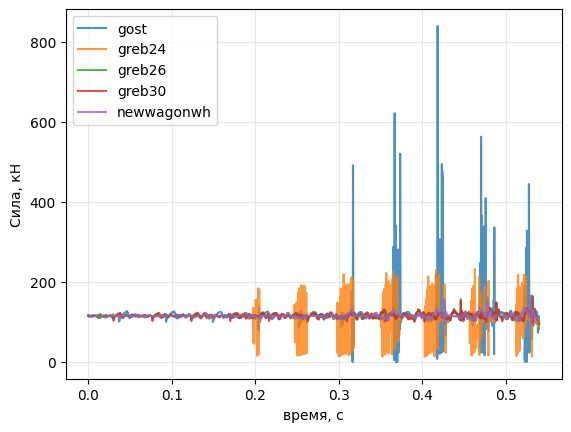

In [37]:
flag = "vertical"

# Select forces based on flag
forces_to_plot = side_forces if flag == "side" else vertical_forces

# Calculate wheel rotation period and convert to time
wheel_radius = 0.955  # meters
speed_kmh = 40
speed_ms = speed_kmh / 3.6  # convert to m/s
wheel_circumference = 2 * np.pi * wheel_radius
rotation_period = wheel_circumference / speed_ms  # seconds

# Plot each profile
for profile, force_data in forces_to_plot.items():
    time_array = np.arange(len(force_data)) * (rotation_period / len(force_data))
    plt.plot(time_array, force_data, label=profile, alpha=0.8, linewidth=1.5)

# plt.xlim((0, 600))
# if flag == "vertical":
#     plt.ylim((80, 150))
# else:
#     plt.ylim((-15, 15))

plt.ylabel("Сила, кН")
plt.xlabel("время, с")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

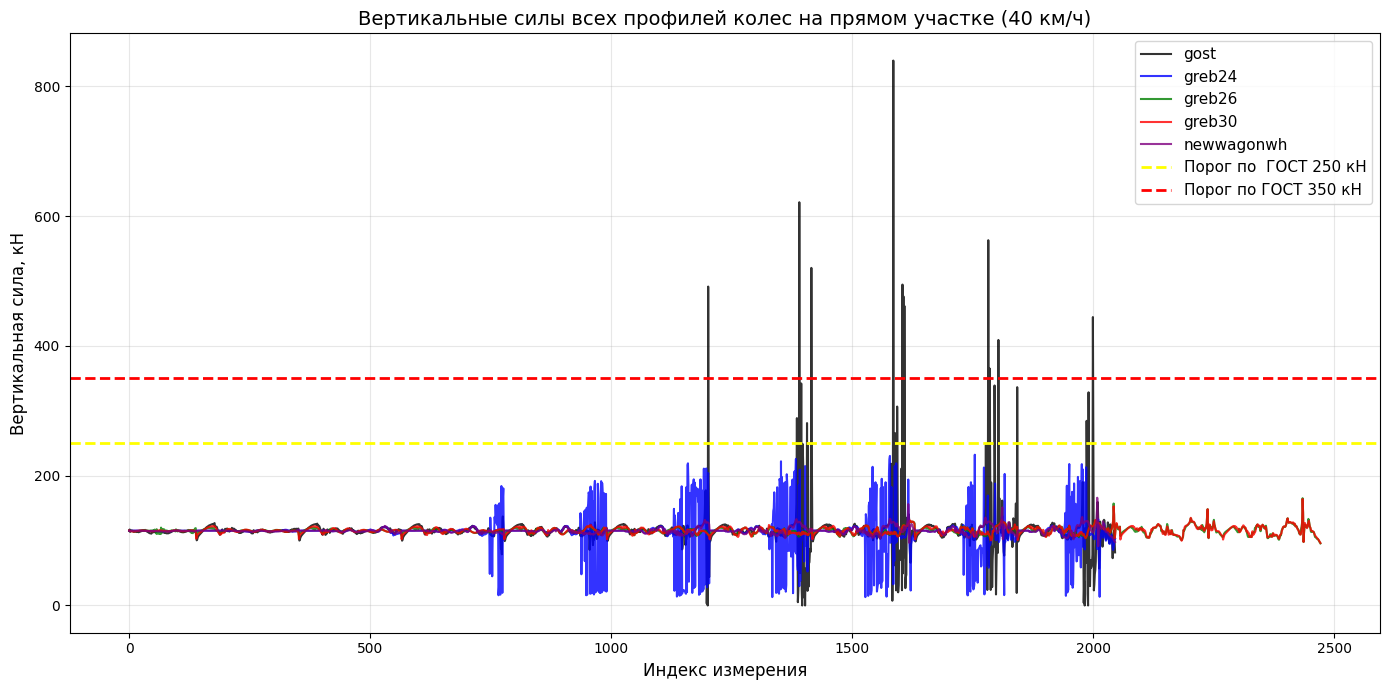


=== Статистика вертикальные силы по профилям ===

GOST:
  Среднее:        116.529 кН
  Мин:              0.000 кН
  Макс:           839.833 кН
  Стд.откл.:       38.164 кН
  delta min-max:         839.833 кН
  Кол-во точек:  2046/2046

GREB24:
  Среднее:        112.590 кН
  Мин:             12.890 кН
  Макс:           232.352 кН
  Стд.откл.:       29.759 кН
  delta min-max:         219.462 кН
  Кол-во точек:  2046/2046

GREB26:
  Среднее:        115.594 кН
  Мин:             95.689 кН
  Макс:           165.353 кН
  Стд.откл.:        4.957 кН
  delta min-max:          69.663 кН
  Кол-во точек:  2472/2472

GREB30:
  Среднее:        115.747 кН
  Мин:             96.326 кН
  Макс:           164.097 кН
  Стд.откл.:        5.247 кН
  delta min-max:          67.771 кН
  Кол-во точек:  2472/2472

NEWWAGONWH:
  Среднее:        115.357 кН
  Мин:             91.448 кН
  Макс:           166.058 кН
  Стд.откл.:        4.848 кН
  delta min-max:          74.611 кН
  Кол-во точек:  2046/2046


In [13]:
# Визуализация сил всех профилей колес
# ВЫБОР ТИПА СИЛЫ: 'side' или 'vertical'
force_type = 'vertical'  # Измените на 'vertical' для вертикальных сил

# Выбираем данные
if force_type == 'side':
    forces_data = side_forces
    force_label = 'Боковая сила'
    title_suffix = 'Боковые силы'
elif force_type == 'vertical':
    forces_data = vertical_forces
    force_label = 'Вертикальная сила'
    title_suffix = 'Вертикальные силы'
else:
    raise ValueError("force_type должен быть 'side' или 'vertical'")

plt.figure(figsize=(14, 7))

# Цвета для каждого профиля
colors = {
    'gost': 'black',
    'greb24': 'blue',
    'greb26': 'green',
    'greb30': 'red',
    'newwagonwh': 'purple'
}

# Рисуем графики для каждого профиля
for profile, force_data in forces_data.items():
    plt.plot(force_data, label=profile, linewidth=1.5, color=colors.get(profile, 'gray'), alpha=0.8)

# Пороги ГОСТ для вертикальной силы
if force_type == 'vertical':
    plt.axhline(250, color='yellow', linewidth=2, linestyle='--', label='Порог по  ГОСТ 250 кН')
    plt.axhline(350, color='red', linewidth=2, linestyle='--', label='Порог по ГОСТ 350 кН')

plt.xlabel('Индекс измерения', fontsize=12)
plt.ylabel(f'{force_label}, кН', fontsize=12)
plt.title(f'{title_suffix} всех профилей колес на прямом участке (40 км/ч)', fontsize=14)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Выводим статистику (игнорируем NaN значения)
print(f"\n=== Статистика {title_suffix.lower()} по профилям ===")
for profile, force_data in forces_data.items():
    valid_data = force_data[~np.isnan(force_data)]
    print(f"\n{profile.upper()}:")
    print(f"  Среднее:       {np.mean(valid_data):8.3f} кН")
    print(f"  Мин:           {np.min(valid_data):8.3f} кН")
    print(f"  Макс:          {np.max(valid_data):8.3f} кН")
    print(f"  Стд.откл.:     {np.std(valid_data):8.3f} кН")
    print(f"  delta min-max:        {np.max(valid_data) - np.min(valid_data):8.3f} кН")
    print(f"  Кол-во точек:  {len(valid_data)}/{len(force_data)}")


=== Загрузка исходных данных (как они есть в файлах) ===

✓ GOST        : 113326 точек
✓ GREB24      : 112366 точек
✓ GREB26      : 113326 точек
✓ GREB30      : 113326 точек
✓ NEWWAGONWH  : 113326 точек


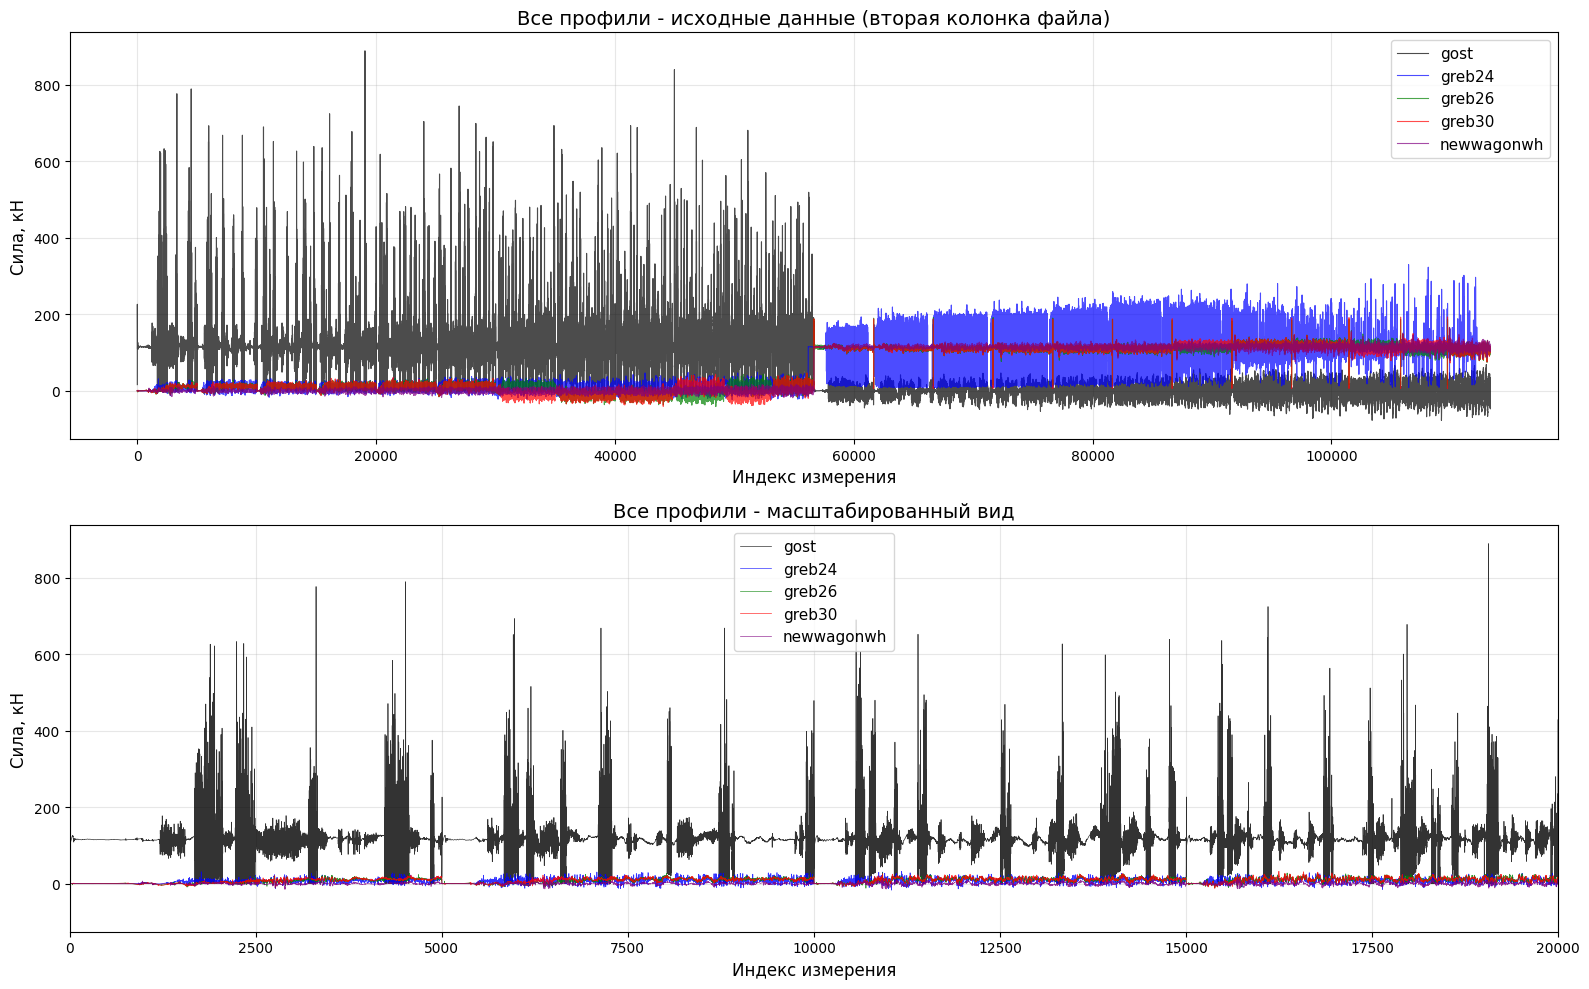


=== Статистика исходных данных ===

GOST:
  Среднее:         57.469 кН
  Мин:            -77.326 кН
  Макс:           889.139 кН
  Стд.откл.:       70.839 кН
  Размах:         966.465 кН

GREB24:
  Среднее:         59.045 кН
  Мин:            -23.027 кН
  Макс:           330.112 кН
  Стд.откл.:       63.206 кН
  Размах:         353.139 кН

GREB26:
  Среднее:         58.881 кН
  Мин:            -41.164 кН
  Макс:           191.602 кН
  Стд.откл.:       55.194 кН
  Размах:         232.767 кН

GREB30:
  Среднее:         58.378 кН
  Мин:            -40.503 кН
  Макс:           193.085 кН
  Стд.откл.:       56.454 кН
  Размах:         233.588 кН

NEWWAGONWH:
  Среднее:         57.638 кН
  Мин:            -18.047 кН
  Макс:           166.058 кН
  Стд.откл.:       57.719 кН
  Размах:         184.106 кН


In [25]:
# Загрузим сырые данные и посмотрим их как есть
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== Загрузка исходных данных (как они есть в файлах) ===\n")

data_path = "../data/loaded/v1/"
profiles_to_plot = ['gost', 'greb24', 'greb26', 'greb30', 'newwagonwh']

raw_data = {}

for profile in profiles_to_plot:
    filename = f"loaded_straight_{profile}.csv"
    filepath = os.path.join(data_path, filename)
    
    if os.path.exists(filepath):
        try:
            # Загружаем исходные данные как есть
            df = pd.read_csv(filepath, encoding='latin-1')
            
            # Берем вторую колонку (индекс 1)
            if df.shape[1] > 1:
                data = df.iloc[:, 1].values / 1000  # конвертируем в кН
                raw_data[profile] = data
                print(f"✓ {profile.upper():12s}: {len(data):6d} точек")
            
        except Exception as e:
            print(f"✗ {profile}: {e}")

# Рисуем графики
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Цвета
colors = {
    'gost': 'black',
    'greb24': 'blue',
    'greb26': 'green',
    'greb30': 'red',
    'newwagonwh': 'purple'
}

# === Все профили на одном графике ===
ax1 = axes[0]
for profile, data in raw_data.items():
    ax1.plot(data, label=profile, linewidth=0.8, color=colors.get(profile, 'gray'), alpha=0.7)

ax1.set_xlabel('Индекс измерения', fontsize=12)
ax1.set_ylabel('Сила, кН', fontsize=12)
ax1.set_title('Все профили - исходные данные (вторая колонка файла)', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# === Отдельные подграфики ===
ax2 = axes[1]
for profile, data in raw_data.items():
    ax2.plot(data, label=profile, linewidth=0.5, color=colors.get(profile, 'gray'), alpha=0.8)

ax2.set_xlabel('Индекс измерения', fontsize=12)
ax2.set_ylabel('Сила, кН', fontsize=12)
ax2.set_title('Все профили - масштабированный вид', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 20000)  # Зум на первую часть

plt.tight_layout()
plt.show()

# Статистика
print("\n=== Статистика исходных данных ===")
for profile, data in raw_data.items():
    print(f"\n{profile.upper()}:")
    print(f"  Среднее:       {np.mean(data):8.3f} кН")
    print(f"  Мин:           {np.min(data):8.3f} кН")
    print(f"  Макс:          {np.max(data):8.3f} кН")
    print(f"  Стд.откл.:     {np.std(data):8.3f} кН")
    print(f"  Размах:        {np.max(data) - np.min(data):8.3f} кН")


In [16]:
# Диагностика: почему только у GOST вертикальная сила?
print("=== ВЫВОД: Почему только GOST имеет вертикальные силы? ===\n")

print("Исходные данные имеют РАЗНЫЕ СТРУКТУРЫ для разных профилей:")
print("  • В каждом файле есть 12 колонок вертикальных и 12 боковых")
print("  • НО валидные данные находятся только в ОДНОМ типе\n")

for profile in ['gost', 'greb24', 'greb26', 'greb30', 'newwagonwh']:
    filepath = f"../data/loaded/v1/loaded_straight_{profile}.csv"
    
    try:
        df = pipe.load_csv(filepath)
        df = pipe._reset_column_names(df)
        
        vertical_cols = [col for col in df.columns if 'vertical' in col.lower()]
        side_cols = [col for col in df.columns if 'side' in col.lower()]
        
        if vertical_cols:
            v_valid = df[vertical_cols[0]].notna().sum()
        else:
            v_valid = 0
            
        if side_cols:
            s_valid = df[side_cols[0]].notna().sum()
        else:
            s_valid = 0
        
        v_percent = (v_valid / len(df)) * 100 if len(df) > 0 else 0
        s_percent = (s_valid / len(df)) * 100 if len(df) > 0 else 0
        
        v_type = "✓ ВЕРТИКАЛЬНЫЕ" if v_valid > 0 else "✗ пусто"
        s_type = "✓ БОКОВЫЕ" if s_valid > 0 else "✗ пусто"
        
        print(f"{profile.upper():12s}: {v_type:20s} ({v_percent:5.1f}%)  |  {s_type:20s} ({s_percent:5.1f}%)")
            
    except Exception as e:
        print(f"{profile}: ✗ Ошибка - {e}")

print("\n💡 Объяснение:")
print("  GOST используется при ВЕРТИКАЛЬНОМ измерении силы (тестирование давления)")
print("  Остальные профили (GREB, NEWWAGONWH) используются при БОКОВОМ измерении (тест гравийной дороги)")
print("  Это - различные испытательные конфигурации с разными датчиками!")


=== ВЫВОД: Почему только GOST имеет вертикальные силы? ===

Исходные данные имеют РАЗНЫЕ СТРУКТУРЫ для разных профилей:
  • В каждом файле есть 12 колонок вертикальных и 12 боковых
  • НО валидные данные находятся только в ОДНОМ типе

GOST        : ✓ ВЕРТИКАЛЬНЫЕ       (100.0%)  |  ✗ пусто              (  0.0%)
GREB24      : ✗ пусто              (  0.0%)  |  ✓ БОКОВЫЕ            (100.0%)
GREB26      : ✗ пусто              (  0.0%)  |  ✓ БОКОВЫЕ            (100.0%)
GREB30      : ✗ пусто              (  0.0%)  |  ✓ БОКОВЫЕ            (100.0%)
NEWWAGONWH  : ✗ пусто              (  0.0%)  |  ✓ БОКОВЫЕ            (100.0%)

💡 Объяснение:
  GOST используется при ВЕРТИКАЛЬНОМ измерении силы (тестирование давления)
  Остальные профили (GREB, NEWWAGONWH) используются при БОКОВОМ измерении (тест гравийной дороги)
  Это - различные испытательные конфигурации с разными датчиками!


=== Загруженные файлы (как они есть) ===

Найдено файлов: 16
  loaded_straight_gost.csv
  loaded_straight_gost_polzun.csv
  loaded_straight_greb24.csv
  loaded_straight_greb24_ellips.csv
  loaded_straight_greb24_polzun.csv
  loaded_straight_greb26.csv
  loaded_straight_greb26_ellips.csv
  loaded_straight_greb26_polzun.csv
  loaded_straight_greb28_ellips.csv
  loaded_straight_greb28_polzun.csv
  loaded_straight_greb30.csv
  loaded_straight_greb30_ellips.csv
  loaded_straight_greb30_polzun.csv
  loaded_straight_newwagonwh.csv
  loaded_straight_newwagonwh_ellips.csv
  loaded_straight_newwagonwh_polzun.csv


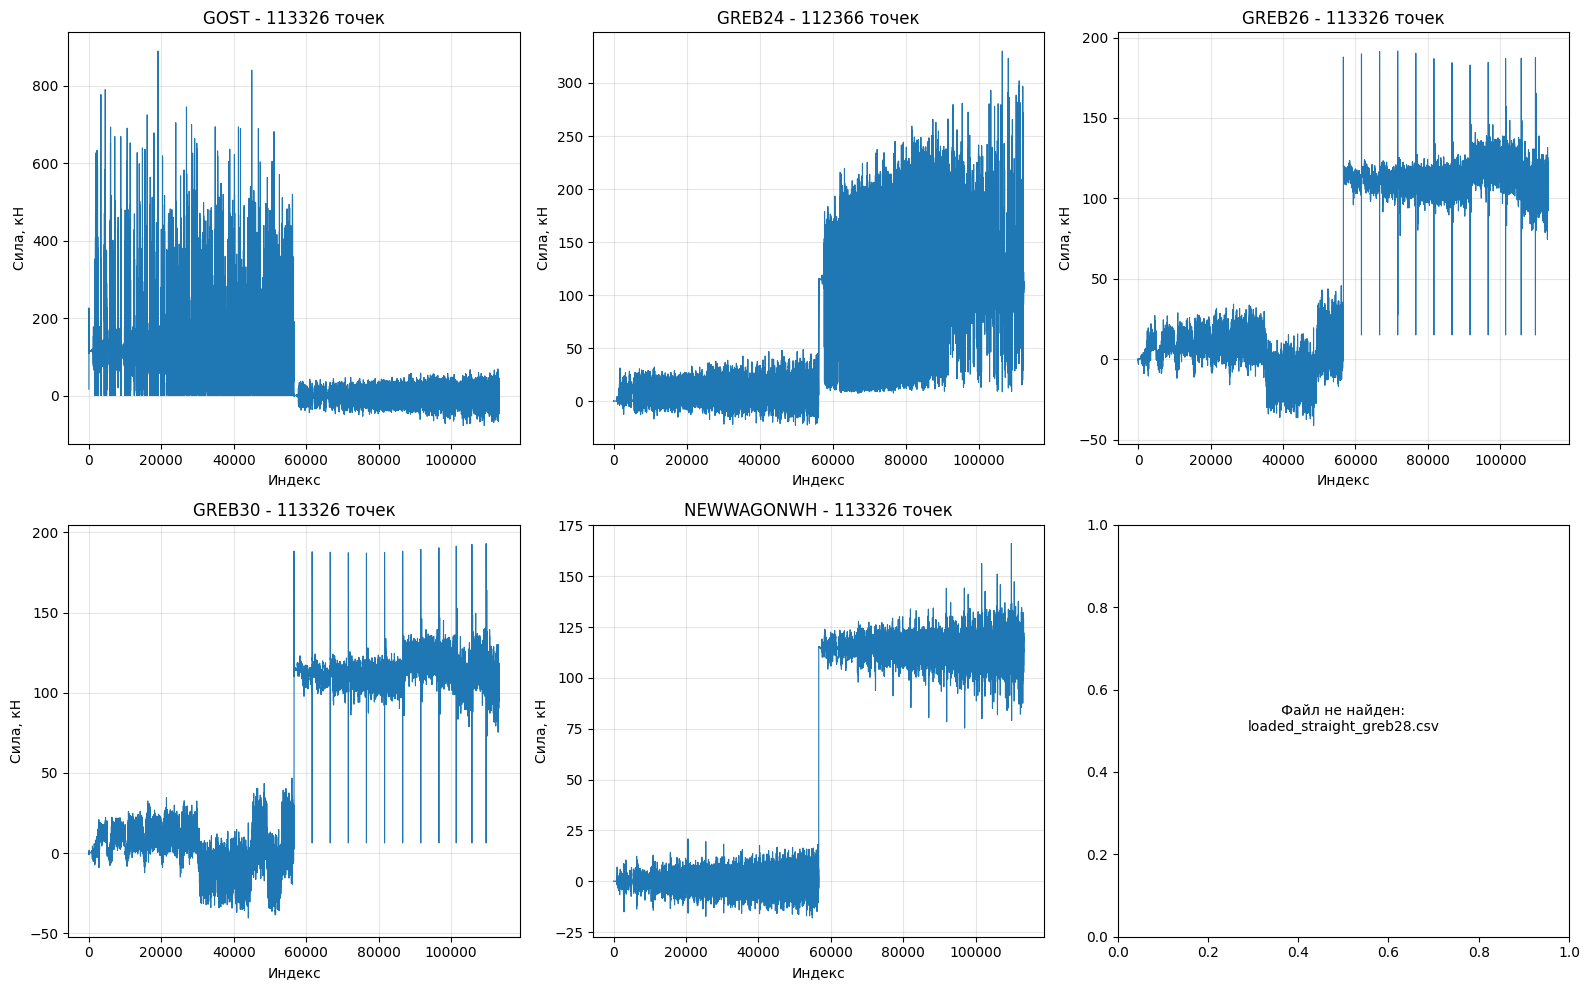

In [24]:
# Простой график: загруженные файлы как они есть
import os
import pandas as pd
import matplotlib.pyplot as plt

print("=== Загруженные файлы (как они есть) ===\n")

# Получаем список файлов
data_path = "../data/loaded/v1/"
files = sorted([f for f in os.listdir(data_path) if "straight" in f and f.endswith(".csv")])

print(f"Найдено файлов: {len(files)}")
for f in files:
    print(f"  {f}")

# Загружаем и рисуем
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

profiles_to_plot = ['gost', 'greb24', 'greb26', 'greb30', 'newwagonwh', 'greb28']

for idx, profile in enumerate(profiles_to_plot):
    filename = f"loaded_straight_{profile}.csv"
    filepath = os.path.join(data_path, filename)
    
    ax = axes[idx]
    
    if os.path.exists(filepath):
        try:
            # Просто загружаем как есть, без обработки
            df = pd.read_csv(filepath, encoding='latin-1')
            
            # Если есть вторая колонка, рисуем её
            if df.shape[1] > 1:
                ax.plot(df.iloc[:, 1] / 1000, linewidth=0.8)
                ax.set_title(f"{profile.upper()} - {df.shape[0]} точек")
                ax.set_xlabel("Индекс")
                ax.set_ylabel("Сила, кН")
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, f"Нет данных для {profile}", ha='center')
                
        except Exception as e:
            ax.text(0.5, 0.5, f"Ошибка: {e}", ha='center', fontsize=8)
    else:
        ax.text(0.5, 0.5, f"Файл не найден:\n{filename}", ha='center')

# Скрываем лишние оси
for idx in range(len(profiles_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [22]:
# Диагностика: посмотреть колонки в side_blocks
profile = 'greb24'
filepath = f"../data/loaded/v1/loaded_straight_{profile}.csv"

df = pipe.load_csv(filepath)
df = pipe._reset_column_names(df)
idxs = pipe._get_split_index(df)
index_groups = pipe.split_side_vertical(df, idxs)

side_blocks = pipe._split(df, index_groups, vertical=False)
print(f"side_blocks[0].shape: {side_blocks[0].shape}")
print(f"side_blocks[0].columns: {list(side_blocks[0].columns)}")

# После split_by_time
side_segments = pipe.split_by_time(side_blocks)
print(f"\nПосле split_by_time:")
print(f"  Количество segments: {len(side_segments)}")
if side_segments:
    print(f"  side_segments[0].shape: {side_segments[0].shape}")
    print(f"  side_segments[0].columns: {list(side_segments[0].columns)}")
    
# После update_column_names
side_segments = pipe.update_column_names(side_segments, False)
print(f"\nПосле update_column_names:")
if side_segments:
    print(f"  side_segments[0].shape: {side_segments[0].shape}")
    print(f"  side_segments[0].columns: {list(side_segments[0].columns)}")
    # Попробуем взять значения
    if side_segments[0].shape[1] > 1:
        print(f"  side_segments[0].iloc[:, 1] (первые 5): {side_segments[0].iloc[:5, 1].values}")


side_blocks[0].shape: (56183, 1)
side_blocks[0].columns: ['Side 2.78']

После split_by_time:
  Количество segments: 1
  side_segments[0].shape: (2616, 23)
  side_segments[0].columns: ['Side 2.78_0', 'Side 2.78_1', 'Side 2.78_2', 'Side 2.78_3', 'Side 2.78_4', 'Side 2.78_5', 'Side 2.78_6', 'Side 2.78_7', 'Side 2.78_8', 'Side 2.78_9', 'Side 2.78_10', 'Side 2.78_11', 'Side 2.78_12', 'Side 2.78_13', 'Side 2.78_14', 'Side 2.78_15', 'Side 2.78_16', 'Side 2.78_17', 'Side 2.78_18', 'Side 2.78_19', 'Side 2.78_20', 'Side 2.78_21', 'Side 2.78_22']

После update_column_names:
  side_segments[0].shape: (2616, 23)
  side_segments[0].columns: ['Side 2.78_0', 'Side 2.78_1', 'Side 2.78_2', 'Side 2.78_3', 'Side 2.78_4', 'Side 2.78_5', 'Side 2.78_6', 'Side 2.78_7', 'Side 2.78_8', 'Side 2.78_9', 'Side 2.78_10', 'Side 2.78_11', 'Side 2.78_12', 'Side 2.78_13', 'Side 2.78_14', 'Side 2.78_15', 'Side 2.78_16', 'Side 2.78_17', 'Side 2.78_18', 'Side 2.78_19', 'Side 2.78_20', 'Side 2.78_21', 'Side 2.78_22']
  side